# Storm tracking
This notebook is for running the storm tracking algorithm and creating the diagnostics plots to observe the general and individual results. For running the results you need the storm catalog output from the RaindyDay, the shapefiles of the transposition domain and control area, and the following packages.


In [2]:
#Packages:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from pyproj import Transformer # convert lat/lon to projected coordinates
from geographiclib.geodesic import Geodesic # compute storm centroid movement
import geopandas as gpd # read shapefiles
import os
import pandas as pd
import scrapbook as sb
import sys
import seaborn as sns

### Storm tracking packages
The following packages need to be in the same folder as this notebook

In [3]:
from pathlib import Path


# add project root (parent of Notebooks/) to sys.path
root = Path.cwd().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))



# Import storm dataset and related modules
from functions.storm_dataset import storm_tracking_event, continuos_storm, storm_tracking_features
from functions.storm_direction import mean_precipitation_within_ellipse, get_max_accumulated_value, compute_line_length, mean_velocity, mean_direction, mean_direction_ln, mean_direction_weighted
from functions.diagnostic_plots import diagnostic_plot_storm_trajectories, plot_storm_track, plot_storm_time_steps

### Storm tracking parameters
Define the parameter for the storm tracking run and analysis


In [4]:
## Storm tracking parameters
morph_radius = 2 # radius for morph structure
high_treshold = 1 # threshold for high precipitation (in mm/hr)
storm_interval = '8H' # storm time interval for getting the most intese precipitation

## Reading control area and transposition domain shapefile
control_area_path = '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/RainyDay_Runs/Run_CONUS/Shapes/control_area_circle_22.0.shp'
transposition_domain_path = "/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/RainyDay_Runs/Run_CONUS/Domains/Domain_22.shp"

# Read the storm catalog
#folder = run_folder +  '/Results/'+ scenario_name+'/StormCatalog/'
catalog_folder  = '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/RainyDay_Runs/Run_CONUS/Results/Domain_22.0_circle_10000km2/StormCatalog'

## Set the path for the output folder and figure path
fig_path ='/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Paper_Notebooks/CONUS DOMAINS/NC_16H'

### Reading storm catalog name files

In [5]:
control_area = gpd.read_file(control_area_path)
transposition_domain = gpd.read_file(transposition_domain_path)
# Get the list of storm events from the catalog folder
domain_name = control_area_path.split('/')[-1].split('_')[3][:4]
event_list = os.listdir(catalog_folder)
event_list = [event for event in event_list if event.endswith('.nc')] ## filter only netcdf files

### Creating folder for saving plots

In [6]:

#create folders for saving plots
storm_track_path = os.path.join(fig_path, 'StormTrack')
if not os.path.exists(storm_track_path):
    os.makedirs(storm_track_path)
storm_time_timesteps_path = os.path.join(fig_path, 'StormTimeSteps')
if not os.path.exists(storm_time_timesteps_path):
    os.makedirs(storm_time_timesteps_path)

### Running the storm tracking algorithm

In [7]:
# create dictionary to store the results
storm_tracking_results = {}

# Iterate over each event in the event_list
event_list.sort()

for event in event_list:
    # Initialize an empty dictionary for each event
    storm_tracking_results[event] = {}

for storm_event in event_list:
    ds = xr.open_dataset(os.path.join(catalog_folder, storm_event)) # Load the dataset
    print(storm_event)
    event_dict = {}
    storm_tracking_event(ds, event_dict, morph_radius=morph_radius, high_threshold=high_treshold)
    if int(event_dict['longest_duration']) <= 6:
        print(f"Skipping event {storm_event} due to short duration: {event_dict['longest_duration']} time steps.")
        continue
    continuos_storm(event_dict)
    storm_tracking_features(event_dict, ellipse_fit="Momentum")
    storm_tracking_results[storm_event] = event_dict # Store the results in the dictionary

IOWA_Domain.nc_storm_100_20100604.nc
The longest storm has a valid duration of 9 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2010-06-04T14:00:00.000000000 to 2010-06-04T23:00:00.000000000
Selected storm duration 10 hours
IOWA_Domain.nc_storm_101_20151116.nc
The longest storm has a valid duration of 4 hours
The selected duration is longer than 0.1 of 24 hours
Skipping event IOWA_Domain.nc_storm_101_20151116.nc due to short duration: 4 time steps.
IOWA_Domain.nc_storm_102_20050506.nc
The longest storm has a valid duration of 5 hours
The selected duration is longer than 0.1 of 24 hours
Skipping event IOWA_Domain.nc_storm_102_20050506.nc due to short duration: 5 time steps.
IOWA_Domain.nc_storm_103_20221210.nc
The longest storm has a valid duration of 1 hours
The selected duration is shorted than 0.1 of 24 hours, skip this event
Skipping event IOWA_Domain.nc_storm_103_20221210.nc due to short duration: 1 time steps.
IOWA_Domain.nc_storm_104_2009102

### Computing storm's speed and direction

In [8]:
# removing empty storms events
storm_tracking_results = {k: v for k, v in storm_tracking_results.items() if v}

# list for storing the results
storm_mean_velocity = []
storm_mean_direction_vector = []
storm_mean_direction_weighted = []
storm_mean_direction_lm = []
position=[]
start_time_list = []


# dictory to store the trajectories in the defined time window
storm_trajectories = {}
# Iterate over each storm event in the tracking results
for storm_event in storm_tracking_results.keys():
    storm = storm_tracking_results[storm_event]
    mean_p_ellipse = mean_precipitation_within_ellipse(storm)
    mean_p = pd.Series(mean_p_ellipse, index=storm['selected_storm_time_steps'].values)
    most_intense_interval = get_max_accumulated_value(mean_p, storm_interval)
    start_time_index = most_intense_interval[3] # start time index 
    end_time_index = most_intense_interval[4] # end time index
    if mean_p_ellipse.min() < 0:
        print(f"Warning: Negative mean precipitation values found in storm {storm_event}. Check the data.")
        continue
    # Getting the centroid coordinates for the start and end time
    x = storm['storm_prj_lon_cent_list'][start_time_index:end_time_index]
    y = storm['storm_prj_lat_cent_list'][start_time_index:end_time_index]

    # compute the length of the trajectory
    trajectory_length = compute_line_length(x, y)

    storm_trajectories[storm_event] = {
        'start_time_index': start_time_index,
        'end_time_index': end_time_index,
        'x_coords': x,
        'y_coords': y,
        'trajectory_length': trajectory_length,
        'mean_precipitation': mean_p_ellipse[start_time_index:end_time_index+1].mean(),
        'storm_id': int(storm_event.split('_storm_')[1].split('_')[0]),  # Extracting storm ID from the filename 
    }
    
    # Compute the mean velocity and direction
    v = mean_velocity(x, y)
    d,vd = mean_direction(x, y)
    wd, wv = mean_direction_weighted(x, y)
    lm = mean_direction_ln(x, y)[0]
    # Append the results to the lists
    storm_mean_velocity.append(v)
    storm_mean_direction_vector.append(d)
    storm_mean_direction_lm.append(lm)
    storm_id = storm_event.split('_storm_')[1].split('_')[0]
    position.append(int(storm_id)) # storm ID
    storm_mean_direction_weighted.append(wd)
    start_time_list.append(storm['selected_storm_time_steps'][start_time_index].values)
    
    # Saving the results for each storm
    storm_tracking_results[storm_event]['mean_velocity'] = v
    storm_tracking_results[storm_event]['mean_direction'] = d
    storm_tracking_results[storm_event]['var_direction'] = vd
    storm_tracking_results[storm_event]['mean_direction_ln'] = lm
    storm_tracking_results[storm_event]['mean_direction_weighted'] = wd
    storm_tracking_results[storm_event]['var_dir_weighted'] = wv
    # Define the transformer for converting projected coordinates to geographic coordinates
transformer = Transformer.from_crs("EPSG:2163", "EPSG:4326", always_xy=True)

# Create a dictionary to store the geographic trajectories
geographic_trajectories = {}

# Iterate over each trajectory in storm_trajectories
for storm_event, traj in storm_trajectories.items():
    x_coords = traj['x_coords']
    y_coords = traj['y_coords']
    
    # Transform the coordinates
    lon_coords, lat_coords = transformer.transform(x_coords, y_coords)
    
    # Store the geographic coordinates in the dictionary
    geographic_trajectories[storm_event] = {
        'start_time_index': traj['start_time_index'],
        'end_time_index': traj['end_time_index'],
        'lon_coords': lon_coords,
        'lat_coords': lat_coords,
        'trajectory_length': traj['trajectory_length']
    }
#save the properties in dataframe
storm_properties = pd.DataFrame({
    'storm_id': position,
    'start_time': start_time_list,
    'mean_velocity': storm_mean_velocity,
    'mean_direction_vector': storm_mean_direction_vector,
    'mean_direction_lm': storm_mean_direction_lm,
    'mean_direction_weighted': storm_mean_direction_weighted
})
storm_properties.index = storm_properties['start_time']
storm_properties = storm_properties.sort_index()
df = pd.DataFrame.from_dict(storm_trajectories,orient='index')

/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer/functions/storm_direction.py:185: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  window = pd.to_timedelta(window)


In [9]:
storm_properties

,storm_id,start_time,mean_velocity,mean_direction_vector,mean_direction_lm,mean_direction_weighted
start_time,,,,,,
2002-01-21 23:00:00,369,2002-01-21 23:00:00,4.114315,-92.212582,70.580216,-109.227738
2002-01-28 09:00:00,258,2002-01-28 09:00:00,12.406207,-67.091511,37.824921,-108.451545
2002-03-07 00:00:00,339,2002-03-07 00:00:00,10.601484,10.518901,22.882844,20.638097
2002-04-16 04:00:00,303,2002-04-16 04:00:00,2.045384,55.728568,5.690204,54.610585
2002-04-27 13:00:00,2,2002-04-27 13:00:00,6.662456,49.683909,34.101591,43.812365
...,...,...,...,...,...,...
2022-11-05 05:00:00,254,2022-11-05 05:00:00,10.682948,-8.787607,12.019366,-32.125264
2022-11-09 01:00:00,286,2022-11-09 01:00:00,10.425105,66.556607,56.921628,59.273653
2022-12-02 04:00:00,31,2022-12-02 04:00:00,16.683233,-69.771467,77.115354,-91.935963


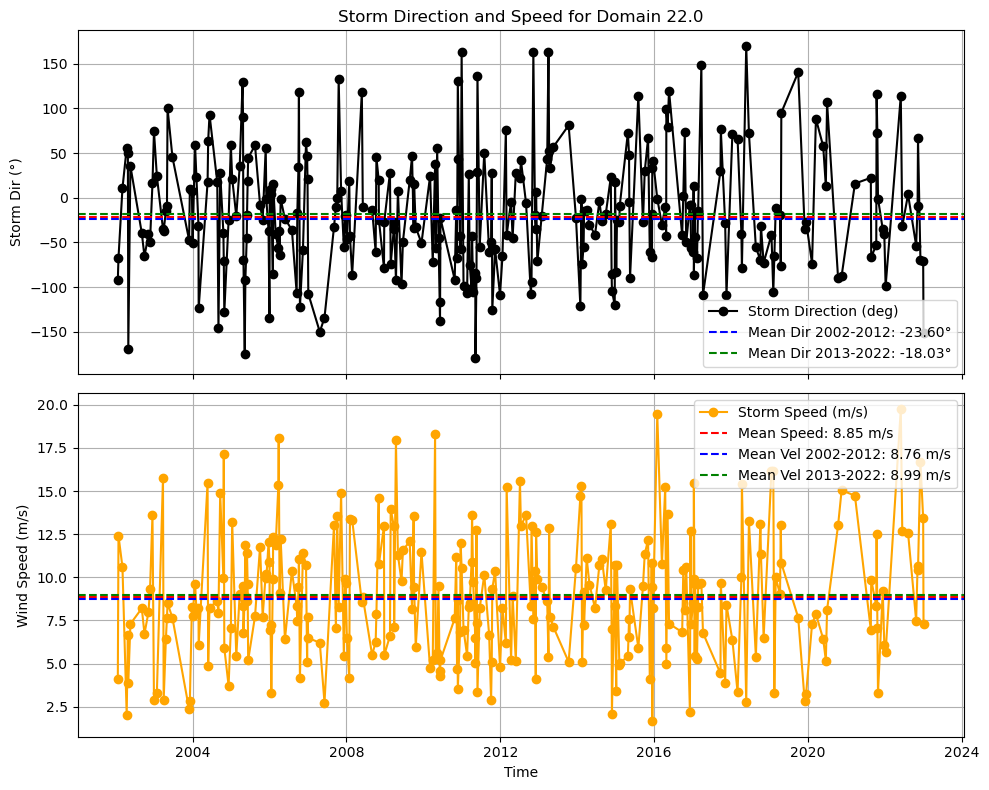

In [18]:


# Sample time series (replace with your own data)
# Wind direction in degrees (from which the wind blows)
theta_deg  = storm_properties['mean_direction_vector']
wind_speed = storm_properties['mean_velocity']  # Optional: constant speed = 5 m/s

# Convert to radians
theta_rad = np.radians(theta_deg)
# Compute mean angle using circular statistics
mean_angle = np.degrees(
    np.arctan2(np.mean(np.sin(theta_rad)), np.mean(np.cos(theta_rad)))
)

# Plotting
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Wind direction
ax[0].plot(theta_deg, label='Storm Direction (deg)', color='black', marker='o')
ax[0].axhline(mean_angle, color='red', linestyle='--')
ax[0].set_ylabel('Storm Dir (°)')
ax[0].set_title('Storm Direction and Speed for Domain '+ domain_name)
ax[0].grid()
ax[0].legend()

# wind direction means
dir_2002_2012 = storm_properties['mean_direction_vector'].loc['2002-01-01':'2012-12-31']
mean_dir_2002_2012 = dir_2002_2012=np.degrees(
    np.arctan2(np.mean(np.sin(np.radians(dir_2002_2012))), 
               np.mean(np.cos(np.radians(dir_2002_2012))))
)
ax[0].axhline(mean_dir_2002_2012, color='blue', linestyle='--', label=f'Mean Dir 2002-2012: {mean_dir_2002_2012:.2f}°')
dir_2013_2022 = storm_properties['mean_direction_vector'].loc['2013-01-01':'2022-12-31']
mean_dir_2013_2022 = dir_2013_2022=np.degrees(
    np.arctan2(np.mean(np.sin(np.radians(dir_2013_2022))), 
               np.mean(np.cos(np.radians(dir_2013_2022))))
)
ax[0].axhline(mean_dir_2013_2022, color='green', linestyle='--', label=f'Mean Dir 2013-2022: {mean_dir_2013_2022:.2f}°')
ax[0].legend()


# wind speed
ax[1].plot(wind_speed, label = 'Storm Speed (m/s)', color='orange', marker='o')
ax[1].set_ylabel('Wind Speed (m/s)')
ax[1].set_xlabel('Time')
ax[1].grid()
# mean wind speed
mean_speed = wind_speed.mean()
ax[1].axhline(mean_speed, color='red', linestyle='--', label=f'Mean Speed: {mean_speed:.2f} m/s')
ax[1].legend()
vel_2002_2012 = storm_properties['mean_velocity'].loc['2002-01-01':'2012-12-31']
mean_vel_2002_2012 = vel_2002_2012.mean()
ax[1].axhline(mean_vel_2002_2012, color='blue', linestyle='--', label=f'Mean Vel 2002-2012: {mean_vel_2002_2012:.2f} m/s')
vel_2013_2022 = storm_properties['mean_velocity'].loc['2013-01-01':'2022-12-31']
mean_vel_2013_2022 = vel_2013_2022.mean()
ax[1].axhline(mean_vel_2013_2022, color='green', linestyle='--', label=f'Mean Vel 2013-2022: {mean_vel_2013_2022:.2f} m/s')
ax[1].legend()

#velocity slope
vel_slope = np.polyfit(np.arange(len(wind_speed)), wind_speed, 1)[0]

plt.tight_layout()
plt.show()

/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_7293/273373085.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_direction = storm_properties['mean_direction_vector'].resample('M').apply(lambda x: np.arctan2(np.mean(np.sin(np.radians(x))), np.mean(np.cos(np.radians(x)))) * (180/np.pi) % 360)
/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_7293/273373085.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_velocity = storm_properties['mean_velocity'].resample('M').mean()


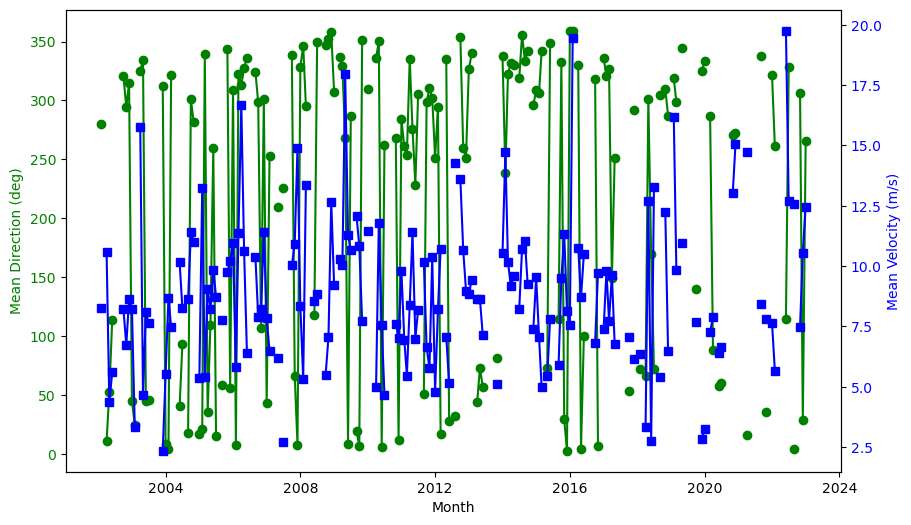

In [26]:
# monthly angle mean and velocity

monthly_direction = storm_properties['mean_direction_vector'].resample('M').apply(lambda x: np.arctan2(np.mean(np.sin(np.radians(x))), np.mean(np.cos(np.radians(x)))) * (180/np.pi) % 360)
monthly_mean_direction =monthly_direction.groupby(by=monthly_direction.index.month).apply(lambda x: np.arctan2(np.mean(np.sin(np.radians(x))), np.mean(np.cos(np.radians(x)))) * (180/np.pi) % 360)
monthly_velocity = storm_properties['mean_velocity'].resample('M').mean()
# Plotting

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()
ax1.plot(monthly_direction.index, monthly_direction, 'g-o', label='Mean Direction (deg)')
ax2.plot(monthly_velocity.index, monthly_velocity, 'b-s', label='Mean Velocity (m/s)')

ax1.set_xlabel('Month')
ax1.set_ylabel('Mean Direction (deg)', color='g')
ax2.set_ylabel('Mean Velocity (m/s)', color='b')
ax1.tick_params(axis='y', labelcolor='g')
ax2.tick_params(axis='y', labelcolor='b')

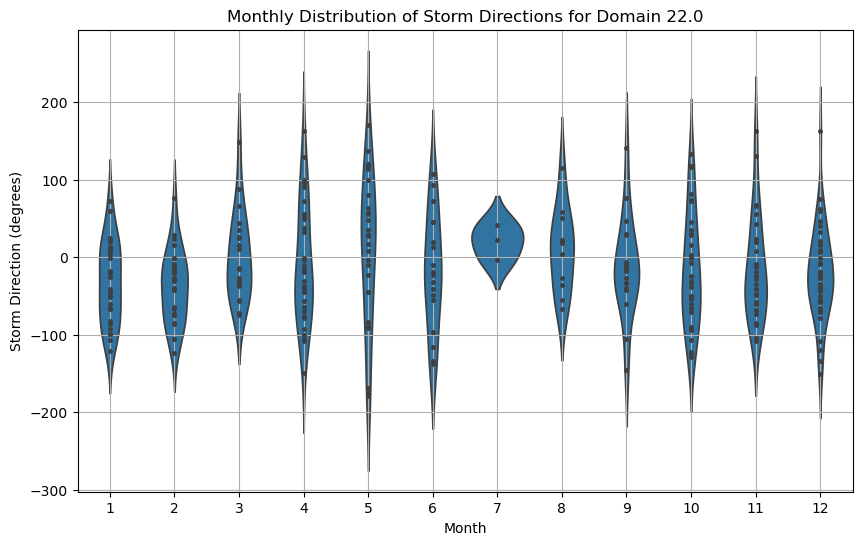

In [10]:
# violin plot for monthly direction
plt.figure(figsize=(10, 6))
sns.violinplot(x=storm_properties.index.month, y=storm_properties['mean_direction_vector'], inner='point')
# Add mean direction line
mean_monthly_direction = storm_properties['mean_direction_vector'].groupby(storm_properties.index.month).mean()
plt.plot(mean_monthly_direction.index - 1, mean_monthly_direction.values, color='red', marker='o', linestyle='--', label='Mean Direction')
plt.xlabel('Month')
plt.ylabel('Storm Direction (degrees)')
plt.title('Monthly Distribution of Storm Directions for Domain '+ domain_name)
plt.grid()
plt.show()

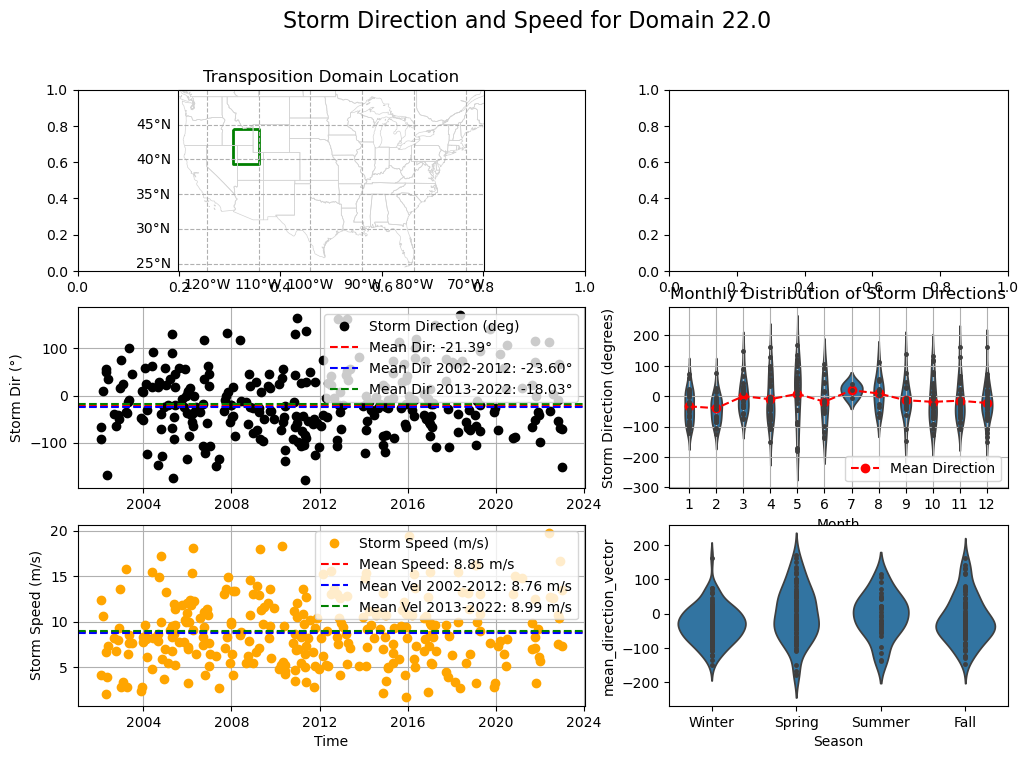

In [49]:
## storm direction and speed plots
fig, ax = plt.subplots(3,2, figsize=(12, 8), gridspec_kw={'width_ratios':[3, 2]})
fig.suptitle('Storm Direction and Speed for Domain '+ domain_name, fontsize=16)
# storm direction subplot
ax[1,0].plot(theta_deg, label='Storm Direction (deg)', color='black',linestyle='None',marker='o')
ax[1,0].axhline(mean_angle, color='red', linestyle='--', label=f'Mean Dir: {mean_angle:.2f}°')
ax[1,0].axhline(mean_dir_2002_2012, color='blue', linestyle='--', label=f'Mean Dir 2002-2012: {mean_dir_2002_2012:.2f}°')
ax[1,0].axhline(mean_dir_2013_2022, color='green', linestyle='--', label=f'Mean Dir 2013-2022: {mean_dir_2013_2022:.2f}°')
ax[1,0].set_ylabel('Storm Dir (°)')
ax[1,0].grid()
ax[1,0].legend()
# storm speed subplot
ax[2,0].plot(wind_speed, label = 'Storm Speed (m/s)', linestyle='None',color='orange', marker='o')
ax[2,0].set_ylabel('Storm Speed (m/s)')
ax[2,0].set_xlabel('Time')
ax[2,0].grid()
ax[2,0].axhline(mean_speed, color='red', linestyle='--', label=f'Mean Speed: {mean_speed:.2f} m/s')
ax[2,0].axhline(mean_vel_2002_2012, color='blue', linestyle='--', label=f'Mean Vel 2002-2012: {mean_vel_2002_2012:.2f} m/s')
ax[2,0].axhline(mean_vel_2013_2022, color='green', linestyle='--', label=f'Mean Vel 2013-2022: {mean_vel_2013_2022:.2f} m/s')
ax[2,0].legend()

# monthly direction violin plot
sns.violinplot(x=storm_properties.index.month, y=storm_properties['mean_direction_vector'], inner='point', ax=ax[1,1])
mean_monthly_direction = storm_properties['mean_direction_vector'].groupby(storm_properties.index.month).mean()
ax[1,1].plot(mean_monthly_direction.index - 1, mean_monthly_direction.values, color='red', marker='o', linestyle='--', label='Mean Direction')
ax[1,1].set_xlabel('Month')
ax[1,1].set_ylabel('Storm Direction (degrees)')
ax[1,1].set_title('Monthly Distribution of Storm Directions')
ax[1,1].grid()
ax[1,1].legend()

# seasonal violin plot
seasons = {1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring', 5: 'Spring', 6: 'Summer', 7: 'Summer', 8: 'Summer', 9: 'Fall', 10: 'Fall', 11: 'Fall', 12: 'Winter'}
storm_properties['Season'] = storm_properties.index.month.map(seasons)
seanson_gropup = storm_properties.groupby('Season')
order = ['Winter', 'Spring', 'Summer', 'Fall']
sns.violinplot(x='Season', y='mean_direction_vector', data=storm_properties, order=order, inner='point', ax=ax[2,1])
import cartopy.crs as ccrs

# location domain
import cartopy.feature as cfeature

# Create a GeoAxes for the map
ax4 = fig.add_subplot(3, 2, 1, projection=ccrs.PlateCarree())  # Use cartopy's PlateCarree projection
ax4.set_title('Transposition Domain Location', fontsize=12)

# Set extent to show the contiguous United States
ax4.set_extent([-125.5, -66.5, 24, 50], crs=ccrs.PlateCarree())

# Plot the transposition domain
transposition_domain.plot(ax=ax4, facecolor='none', edgecolor='green', linewidth=2, label="Transposition Domain")

# Add grid with labeled coordinates
gl4 = ax4.gridlines(draw_labels=True, linestyle='--')
gl4.top_labels = False
gl4.right_labels = False
gl4.xlabel_style = {'size': 10}  # Set font size for x-axis labels
gl4.ylabel_style = {'size': 10}  # Set font size for y-axis labels

# Add U.S. state boundaries
ax4.add_feature(cfeature.STATES, edgecolor='lightgray', linewidth=0.5)







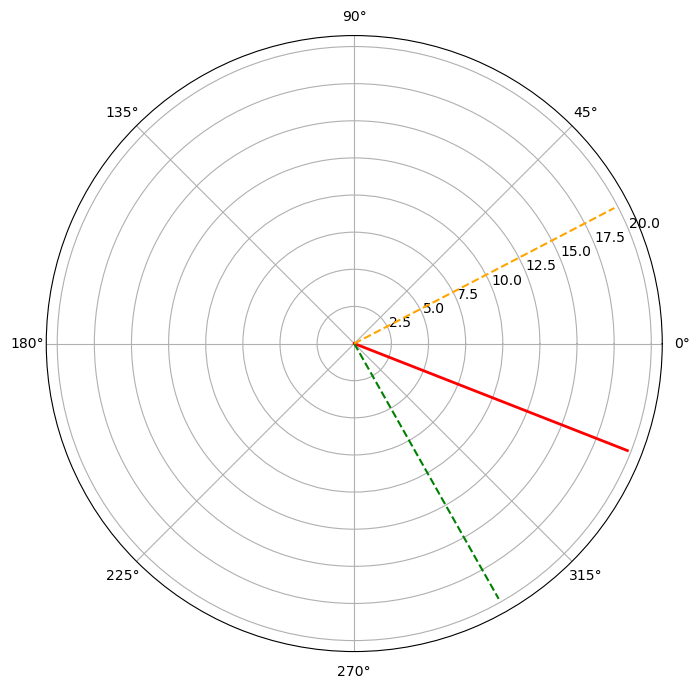

In [48]:
# Rose plot for showing the mean storm direction and 25 75`th percentiles
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)
# Convert degrees to radians for plotting
theta_rad = np.radians(storm_properties['mean_direction_vector'])
# Plot the data points
#ax.scatter(theta_rad, storm_properties['mean_velocity'], c='blue', alpha=0.75, label='Storms')
# Compute and plot the mean direction
mean_dir_rad = np.radians(mean_angle)
mean_speed = storm_properties['mean_velocity'].mean()
ax.plot([mean_dir_rad, mean_dir_rad], [0, storm_properties['mean_velocity'].max()], color='red', linewidth=2, label='Mean Direction')
# Compute and plot the 25th and 75th percentiles
percentile_25 = np.percentile(storm_properties['mean_direction_vector'], 25)
percentile_75 = np.percentile(storm_properties['mean_direction_vector'], 75)
percentile_25_rad = np.radians(percentile_25)
percentile_75_rad = np.radians(percentile_75)
ax.plot([percentile_25_rad, percentile_25_rad], [0, storm_properties['mean_velocity'].max()], color='green', linestyle='--', label='25th Percentile')
ax.plot([percentile_75_rad, percentile_75_rad], [0, storm_properties['mean_velocity'].max()], color='orange', linestyle='--', label='75th Percentile')

In [37]:
storm_properties['Season'] 

start_time
2002-01-21 23:00:00    Winter
2002-01-28 09:00:00    Winter
2002-03-07 00:00:00    Spring
2002-04-16 04:00:00    Spring
2002-04-27 13:00:00    Spring
                        ...  
2022-11-05 05:00:00      Fall
2022-11-09 01:00:00      Fall
2022-12-02 04:00:00    Winter
2022-12-28 04:00:00    Winter
2022-12-31 12:00:00    Winter
Name: Season, Length: 285, dtype: object

Text(0.5, 1.0, 'Monthly Distribution of Storm Velocities for Domain 22.0')

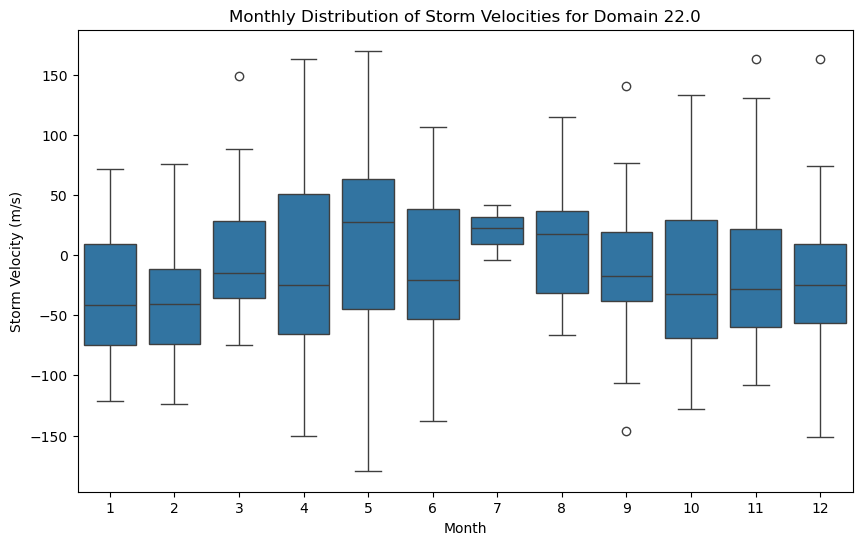

In [12]:
# boxplot for monthly velocity
plt.figure(figsize=(10, 6))
sns.boxplot(x=storm_properties.index.month, y=storm_properties['mean_direction_vector'])
plt.xlabel('Month')
plt.ylabel('Storm Velocity (m/s)')
plt.title('Monthly Distribution of Storm Velocities for Domain '+ domain_name)

<Axes: >

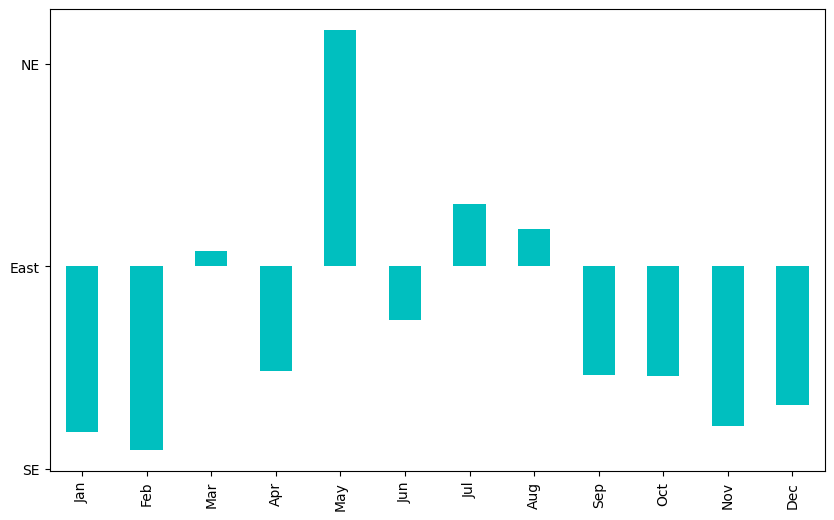

In [28]:
monthly_mean_direction.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_mean_direction[monthly_mean_direction > 180] -= 360  # Convert to -180 to 180 range
fig, ax = plt.subplots(figsize=(10, 6))
# y axis ticks from North (0) clockwise to -180
y_ticks = ['S', 'SE', 'East', 'NE', 'North']
ax.set_yticks([ -90, -45, 0, 45, 90])

ax.set_yticklabels(y_ticks)
monthly_mean_direction.plot(kind='bar', color='c', ax=ax)

/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_14539/1953447968.py:1: FutureWarning: 'Q-DEC' is deprecated and will be removed in a future version, please use 'QE-DEC' instead.
  seansonal_direction = storm_properties['mean_direction_vector'].resample('Q-DEC').apply(lambda x: np.arctan2(np.mean(np.sin(np.radians(x))), np.mean(np.cos(np.radians(x)))) )
/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_14539/1953447968.py:3: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  seasonal_velocity = storm_properties['mean_velocity'].resample('Q').mean()


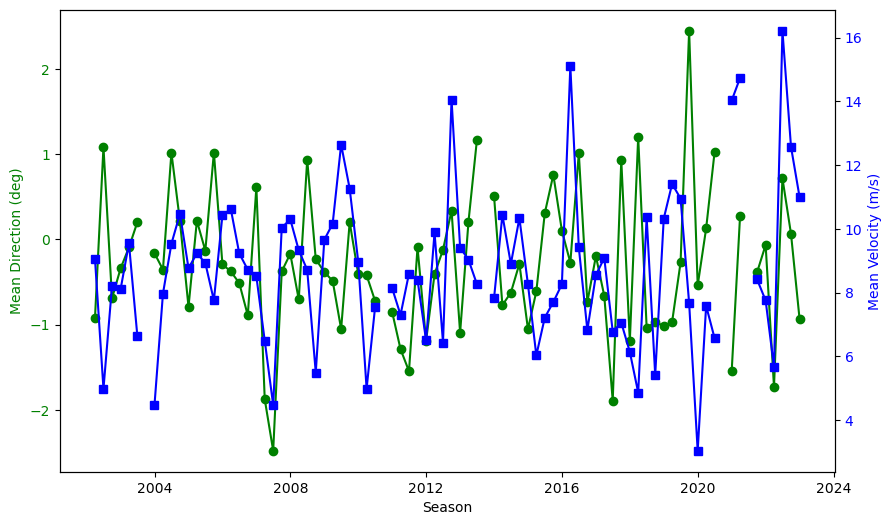

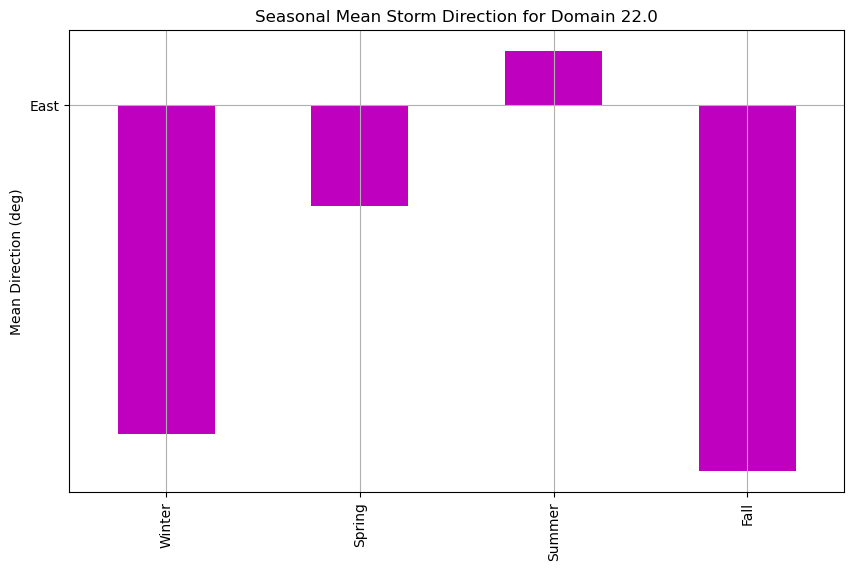

In [71]:
seansonal_direction = storm_properties['mean_direction_vector'].resample('Q-DEC').apply(lambda x: np.arctan2(np.mean(np.sin(np.radians(x))), np.mean(np.cos(np.radians(x)))) )
seasonal_mean_direction =seansonal_direction.groupby(by=seansonal_direction.index.quarter).apply(lambda x: np.arctan2(np.mean(np.sin(np.radians(x))), np.mean(np.cos(np.radians(x)))) )
seasonal_velocity = storm_properties['mean_velocity'].resample('Q').mean()
# Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()
ax1.plot(seansonal_direction.index, seansonal_direction, 'g-o', label='Mean Direction (deg)')
ax2.plot(seasonal_velocity.index, seasonal_velocity, 'b-s', label='Mean Velocity (m/s)')
ax1.set_xlabel('Season')
ax1.set_ylabel('Mean Direction (deg)', color='g')
ax2.set_ylabel('Mean Velocity (m/s)', color='b')
ax1.tick_params(axis='y', labelcolor='g')
ax2.tick_params(axis='y', labelcolor='b')
seasonal_mean_direction.index = ['Winter', 'Spring', 'Summer', 'Fall']
seasonal_mean_direction[seasonal_mean_direction > 180] -= 360  # Convert to -180 to 180 range
fig, ax = plt.subplots(figsize=(10, 6))
# y axis ticks from North (0) clockwise to -180
y_ticks = ['S', 'SE', 'East', 'NE', 'North']
ax.set_yticks([ -90, -45, 0, 45, 90])
ax.set_yticklabels(y_ticks)
seasonal_mean_direction.plot(kind='bar', color='m', ax=ax)
plt.ylabel('Mean Direction (deg)')
plt.title(f'Seasonal Mean Storm Direction for Domain {domain_name}')
plt.grid()

### Creationg diagnostic plots 

/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


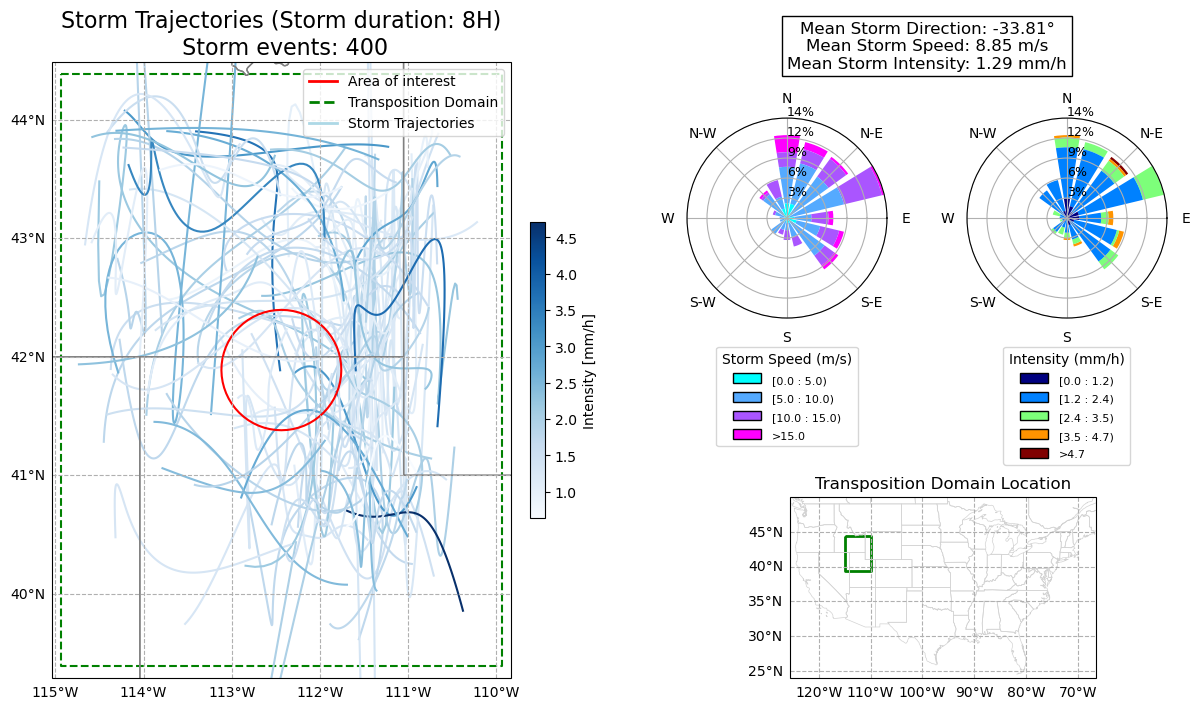

/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


In [10]:
# Create a folder for the diagnostic plots
#diagnostic_plots_folder = os.path.join(scenario_folder, 'Diagnostic_Plots')
longest_trajectories = dict(sorted(storm_trajectories.items(), key=lambda item: item[1]['trajectory_length'], reverse=True)[:100])
mean_angle = np.degrees(np.arctan2(np.mean(np.sin(np.radians(storm_mean_direction_weighted))), 
                                       np.mean(np.cos(np.radians(storm_mean_direction_weighted))))) # mean angle of the storm trajectories
sb.glue('mean_angle', float(mean_angle)) # record the mean angle using papermill
mean_vel = np.mean(storm_mean_velocity) # mean velocity of the storm trajectories
sb.glue('mean_vel', float(mean_vel)) # record the mean velocity using papermill
mean_p = np.mean(mean_p_ellipse)
sb.glue('mean_p', float(mean_p)) # record the mean precipitation using papermill


diagnostic_plot_storm_trajectories(
    df = df, longest_trajectories= longest_trajectories, 
    geographic_trajectories = geographic_trajectories, 
    wsh = control_area, 
    transposition_domain = transposition_domain,
    storm_mean_direction_vector = storm_mean_direction_weighted, 
    storm_mean_velocity = storm_mean_velocity, 
    mean_angle = mean_angle, mean_vel = mean_vel, 
    mean_p_ellipse = mean_p, 
    time_window =  storm_interval,
    save_path = fig_path,
    fig_name = domain_name,
    )

# Save the storm tracking results to a CSV file
tracking_results_df = pd.DataFrame.from_dict(storm_tracking_results, orient='index')
#tracking_results_df.to_csv(os.path.join(folder, 'storm_tracking_results.csv'))

In [12]:
# Plot storm trajectories and time steps


for storm_track in storm_tracking_results.keys():
    plot_storm_track(
        storm_tracking_results = storm_tracking_results, 
        storm_name = storm_track, 
        storm_trajectories = storm_trajectories,
        save_path = storm_track_path)
    
    st = storm_trajectories[storm_track]['start_time_index']
    en = storm_trajectories[storm_track]['end_time_index']
    plot_storm_time_steps(storm_tracking_results=storm_tracking_results,
                          storm_name=storm_track, start_end= (st,en),
                          time_window=storm_interval,
                          save_path=storm_time_timesteps_path)
    

/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/shapely

In [24]:
df_storm = storm_tracking_results['IOWA_Domain.nc_storm_164_20190412.nc']['storm_record']
df_storm[['time','ellipse_angle (degree)']]

,time,ellipse_angle (degree)
0,2019-04-13 05:00:00,67.364691
1,2019-04-13 06:00:00,67.810182
2,2019-04-13 07:00:00,71.127033
3,2019-04-13 08:00:00,65.235357
4,2019-04-13 09:00:00,59.808078
5,2019-04-13 10:00:00,54.642614
6,2019-04-13 11:00:00,68.977581
7,2019-04-13 12:00:00,70.017980
8,2019-04-13 13:00:00,66.295095
9,2019-04-13 14:00:00,55.476992


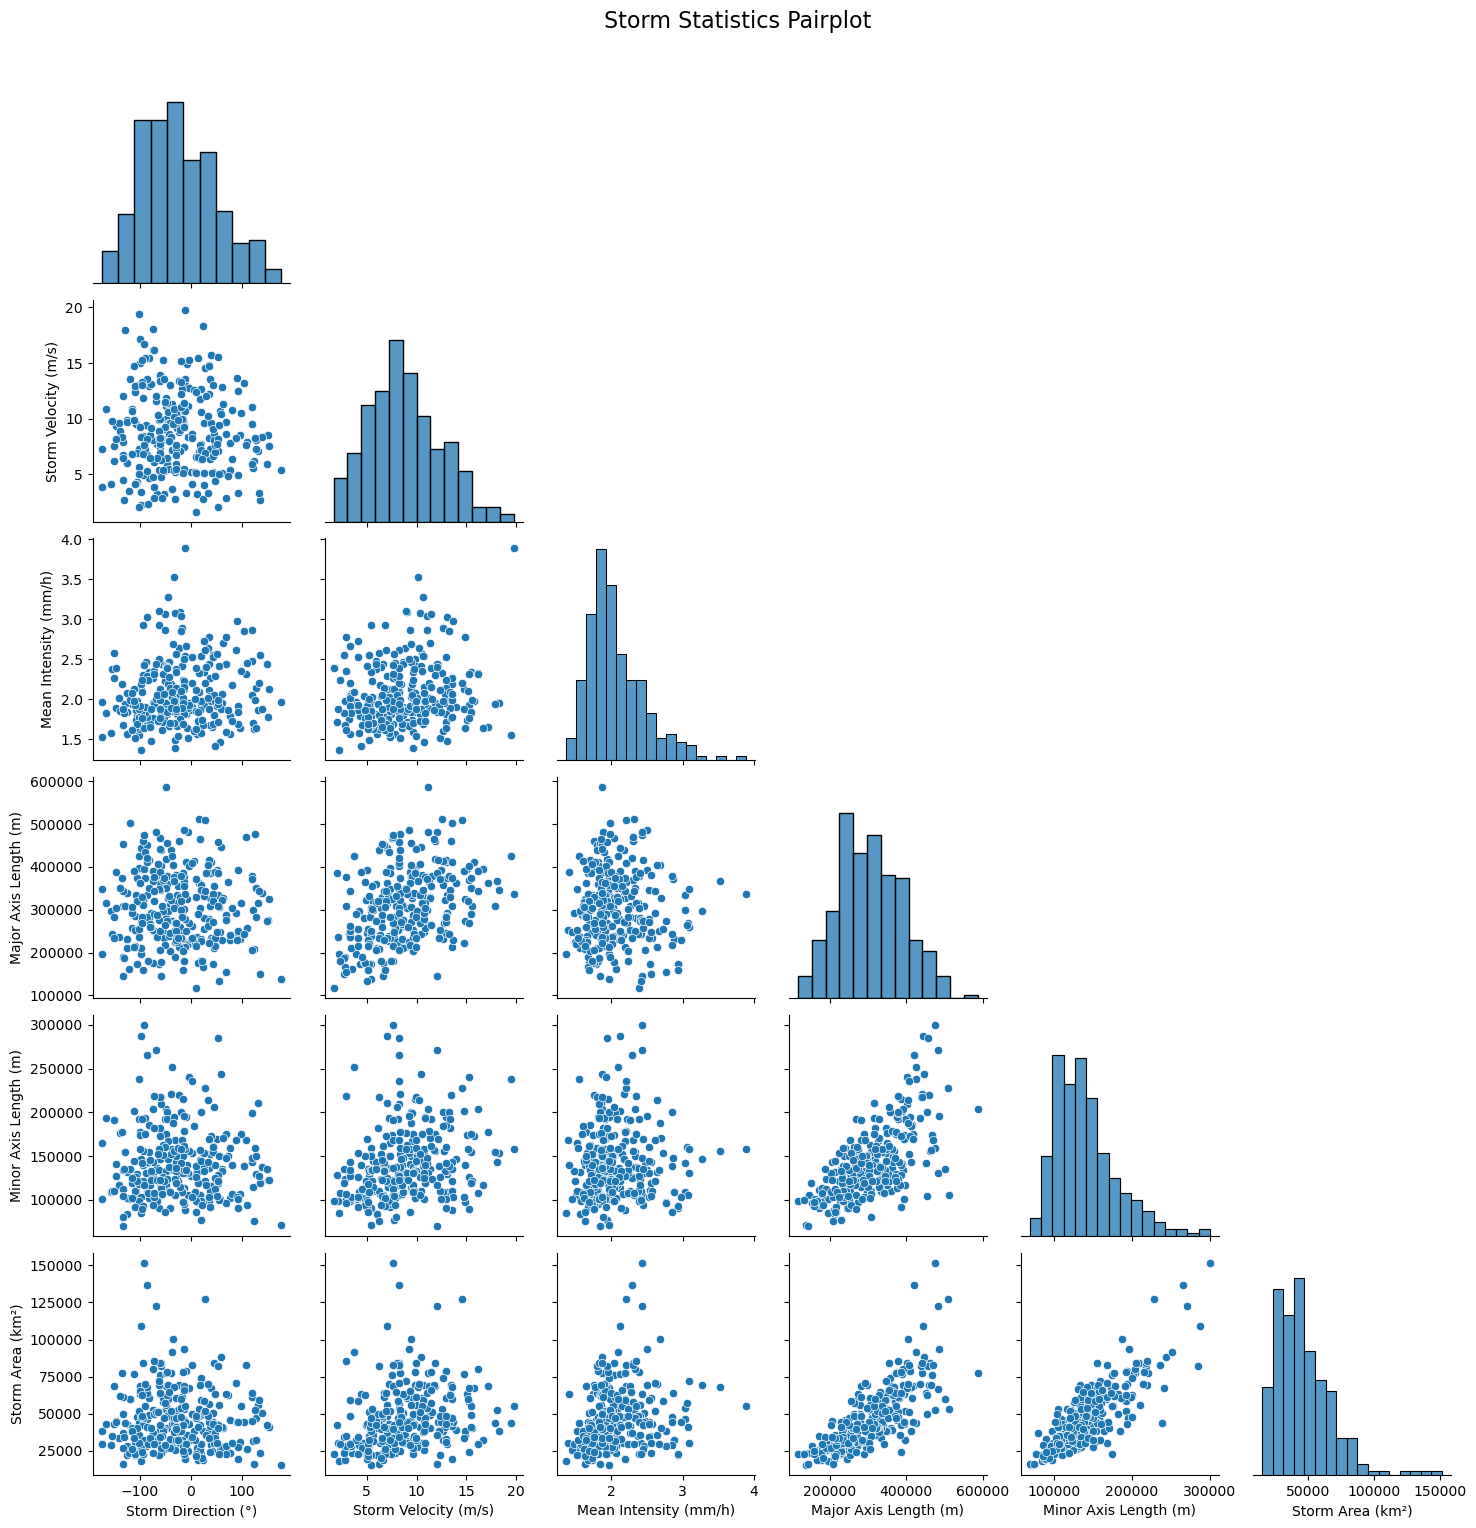

In [15]:
### Storm stats plot

storm_mean_intesity = []
storm_major_radius = []
storm_minus_radius = []
storm_area = []

for storm_event in storm_tracking_results.keys():
    storm = storm_tracking_results[storm_event]
    storm_mean_intesity.append(np.mean(storm['storm_record']['avg_prcp(mm/h)']))
    storm_major_radius.append(np.mean(storm['storm_record']['major_axis_length(m)']))
    storm_minus_radius.append(np.mean(storm['storm_record']['minor_axis_length(m)']))
    storm_area.append(np.mean(storm['selected_storm_area']))

storm_mean_intesity = np.array(storm_mean_intesity)
storm_major_radius = np.array(storm_major_radius)
storm_minus_radius = np.array(storm_minus_radius)
storm_area = np.array(storm_area)
# Create a DataFrame to hold the storm statistics
storm_stats = pd.DataFrame({
    'storm_event': list(storm_tracking_results.keys()),
    'storm_direction': storm_mean_direction_weighted,
    'storm_velocity': storm_mean_velocity,
    'mean_intensity': storm_mean_intesity,
    'major_axis_length': storm_major_radius,
    'minor_axis_length': storm_minus_radius,
    'area': storm_area
})

# Rename columns with descriptive labels + units
storm_stats_renamed = storm_stats.rename(columns={
    'storm_direction': 'Storm Direction (°)',
    'storm_velocity': 'Storm Velocity (m/s)',
    'mean_intensity': 'Mean Intensity (mm/h)',
    'major_axis_length': 'Major Axis Length (m)',
    'minor_axis_length': 'Minor Axis Length (m)',
    'area': 'Storm Area (km²)'  # adjust units if needed
})

## plot the storm statistics with pairplot
sns.pairplot(storm_stats_renamed, diag_kind='hist', markers='o', corner=True)
plt.suptitle('Storm Statistics Pairplot', y=1.02, fontsize=16)
plt.savefig(os.path.join(fig_path, 'storm_statistics_pairplot.png'), dpi=300, bbox_inches='tight')

In [25]:
rad = np.arctan2(-1,1)
np.degrees(rad)

np.float64(-45.0)